In [6]:
import pandas as pd
import numpy as np
import mat73
from scipy import io
from operator import itemgetter

In [11]:
def load_data(filepath, filename):
    data = mat73.loadmat(filepath + '/' + filename)
    X = itemgetter('X')(data) # covariates
    Y = itemgetter('y')(data) # spike counts for each cell
    cell_ids = itemgetter('cell_ids')(data) # the id of each cell (they are concatenated) 
    rec_ids = itemgetter('rec_id')(data)  # the id of each recording (for multiple experiments) 
    return X, Y, cell_ids, rec_ids

def save_data(filepath, filename, results):
    name = filepath + '/' + filename
    io.savemat(name,results)

In [12]:
X, Y, cell_ids, rec_ids = load_data("data/simulated", "test1.mat")

In [13]:
X

array([[-0.64901377,  1.18116604, -0.7584533 , ...,  0.5445917 ,
         0.22682468, -1.08085147],
       [ 0.90001112, -0.42857532,  0.89944987, ..., -1.72436694,
         0.44956979,  0.94353064],
       [-0.43094213, -0.07587645, -1.54328912, ...,  1.38244384,
         1.19434176, -0.11757279],
       [ 0.21489379,  0.33549953, -0.03029765, ...,  0.85432461,
         0.72757149,  2.63936133],
       [ 2.81058991, -0.1099234 ,  1.33210679, ..., -0.79551777,
        -0.21896155, -1.3196753 ]], shape=(5, 15000))

In [14]:
Y

array([0., 5., 0., ..., 1., 1., 0.], shape=(15000,))

In [15]:
cell_ids

array([0., 0., 0., ..., 4., 4., 4.], shape=(15000,))

In [20]:
np.unique(cell_ids, return_counts=True)

(array([0., 1., 2., 3., 4.]), array([3000, 3000, 3000, 3000, 3000]))

In [16]:
rec_ids

array([1., 1., 1., ..., 1., 1., 1.], shape=(15000,))

In [19]:
# unique values + counts
np.unique(rec_ids, return_counts=True)

(array([1.]), array([15000]))

In [22]:
n_features, n_time_x = X.shape      # 5, 15000
n_time_y, = Y.shape               # 15000

In [23]:
n_features, n_time_x, n_time_y

(5, 15000, 15000)

In [37]:
# From this:
# There are 5 cells, each with 3000 time bins → total 15000 time bins.
# •  Y is all spike counts concatenated across cells:
# • 	first 3000 entries → cell 0
# • 	next 3000 → cell 1
# • 	etc.
# •  X has 5 covariates (features), each sampled over 15000 time bins.

# You already have the key:
# • 	5 cells × 3000 time bins = 15000
# • 	120 repeated trials
# So for each cell:
# • 	3000 time bins
# • 	3000 / 120 = 25 time bins per trial
# So the structure is:
# • 	Per cell: 120 trials × 25 time bins
# • 	Per time bin: 5 covariates in X, 1 spike count in Y
n_cells = 5
bins_per_cell = 3000
trials_per_cell = 120
bins_per_trial = bins_per_cell // trials_per_cell  # 25

# sanity check
assert n_cells * bins_per_cell == X.shape[1] == Y.shape[0]

In [24]:
# 3. How to isolate data per cell
# To get X and Y for a single cell:
def get_cell_slice(cell_idx, bins_per_cell=3000):
    start = cell_idx * bins_per_cell
    end = (cell_idx + 1) * bins_per_cell
    return slice(start, end)

cell_idx = 0  # 0..4

cell_slice = get_cell_slice(cell_idx)
X_cell = X[:, cell_slice]        # shape: (5, 3000)
Y_cell = Y[cell_slice]           # shape: (3000,)

In [25]:
X_cell, Y_cell

(array([[-0.64901377,  1.18116604, -0.7584533 , ...,  0.5445917 ,
          0.22682468, -1.08085147],
        [ 0.90001112, -0.42857532,  0.89944987, ..., -1.72436694,
          0.44956979,  0.94353064],
        [-0.43094213, -0.07587645, -1.54328912, ...,  1.38244384,
          1.19434176, -0.11757279],
        [ 0.21489379,  0.33549953, -0.03029765, ...,  0.85432461,
          0.72757149,  2.63936133],
        [ 2.81058991, -0.1099234 ,  1.33210679, ..., -0.79551777,
         -0.21896155, -1.3196753 ]], shape=(5, 3000)),
 array([0., 5., 0., ..., 0., 1., 0.], shape=(3000,)))

In [26]:
# 4. How to isolate data per trial (within a cell)
# Within a cell:
# • 	3000 time bins
# • 	120 trials
# • 	25 bins per trial
def get_cell_trial_slice(cell_idx, trial_idx,
                         bins_per_cell=3000,
                         trials_per_cell=120):
    bins_per_trial = bins_per_cell // trials_per_cell
    cell_start = cell_idx * bins_per_cell
    trial_start = cell_start + trial_idx * bins_per_trial
    trial_end = trial_start + bins_per_trial
    return slice(trial_start, trial_end)

cell_idx = 0      # 0..4
trial_idx = 10    # 0..119

trial_slice = get_cell_trial_slice(cell_idx, trial_idx)
X_trial = X[:, trial_slice]      # shape: (5, 25)
Y_trial = Y[trial_slice]         # shape: (25,)

In [27]:
X_trial, Y_trial

(array([[-8.23197262e-01,  3.31905598e-01,  3.43913883e-01,
          3.79747972e-01,  1.08893930e+00,  9.94859162e-01,
          2.08609505e-01, -3.99187785e-01,  5.06010998e-01,
         -1.27763460e-01, -2.54920829e-01, -7.80433484e-02,
         -3.14649337e-01, -3.08418402e-01,  4.01268224e-01,
         -1.29420672e-01,  1.32768323e+00,  6.70786507e-01,
         -6.91714890e-01, -4.92184407e-02, -3.26730968e-01,
          3.03248303e-01,  2.05650030e+00,  1.70719108e+00,
          5.10741754e-01],
        [-1.50430359e-01, -7.51237323e-01,  8.98460587e-02,
          2.67783090e+00, -8.69180423e-04, -9.40429290e-02,
          1.25418774e+00,  1.09454248e+00, -5.73717761e-01,
          1.58221195e+00,  1.51005907e+00, -1.05657509e+00,
          8.40914644e-02,  5.81723830e-01, -3.33396044e-01,
         -8.71868731e-02,  7.77258543e-01, -1.29389632e+00,
         -4.49303801e-01,  2.92758698e-01, -9.17028830e-01,
          1.60882242e+00,  4.97901343e-01,  1.14063957e+00,
          4.6

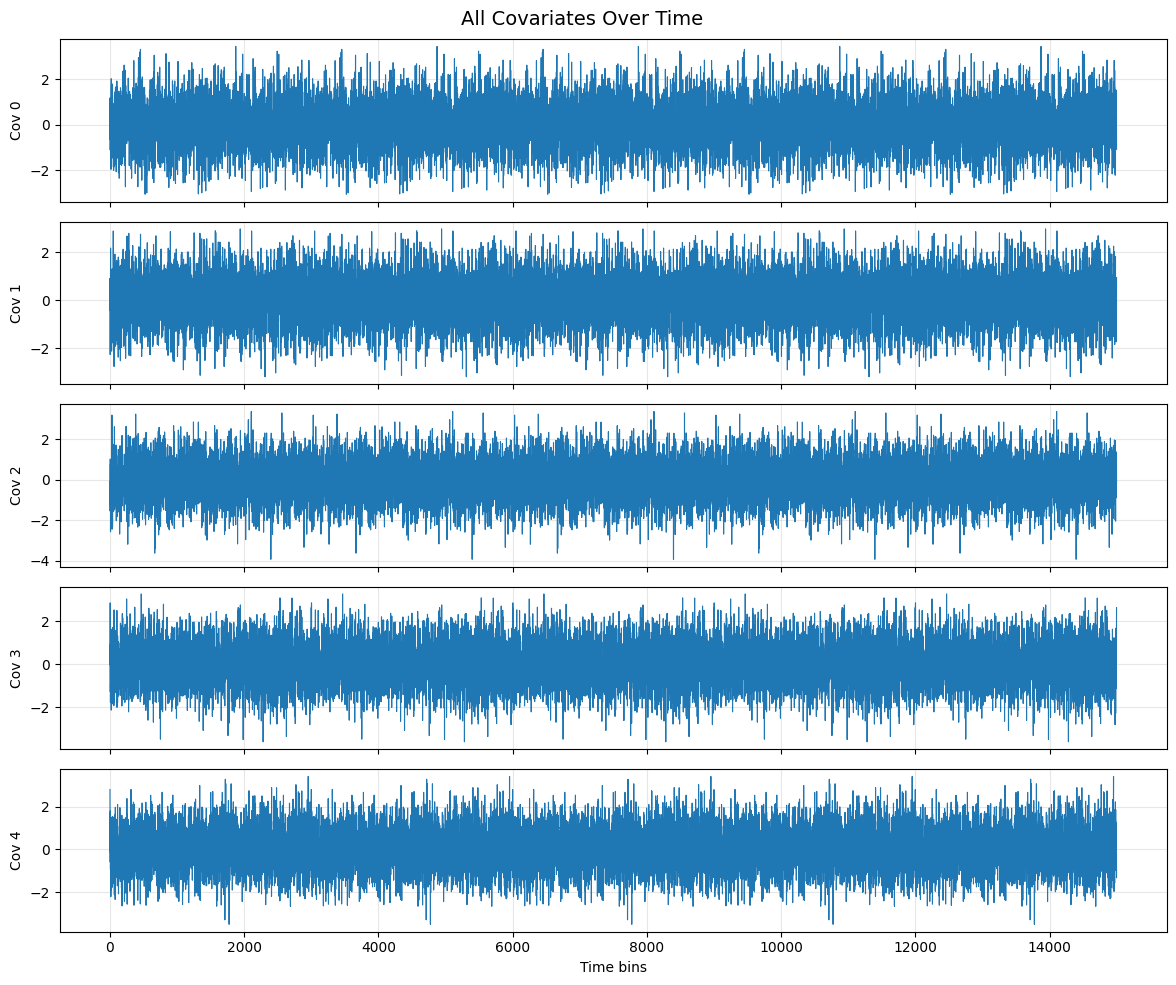

In [30]:
# Plot all covariates across the full recording
import matplotlib.pyplot as plt

def plot_all_covariates(X):
    n_cov = X.shape[0]
    fig, axes = plt.subplots(n_cov, 1, figsize=(12, 2*n_cov), sharex=True)

    for i in range(n_cov):
        axes[i].plot(X[i], linewidth=0.8)
        axes[i].set_ylabel(f"Cov {i}")
        axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time bins")
    plt.suptitle("All Covariates Over Time", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_all_covariates(X)

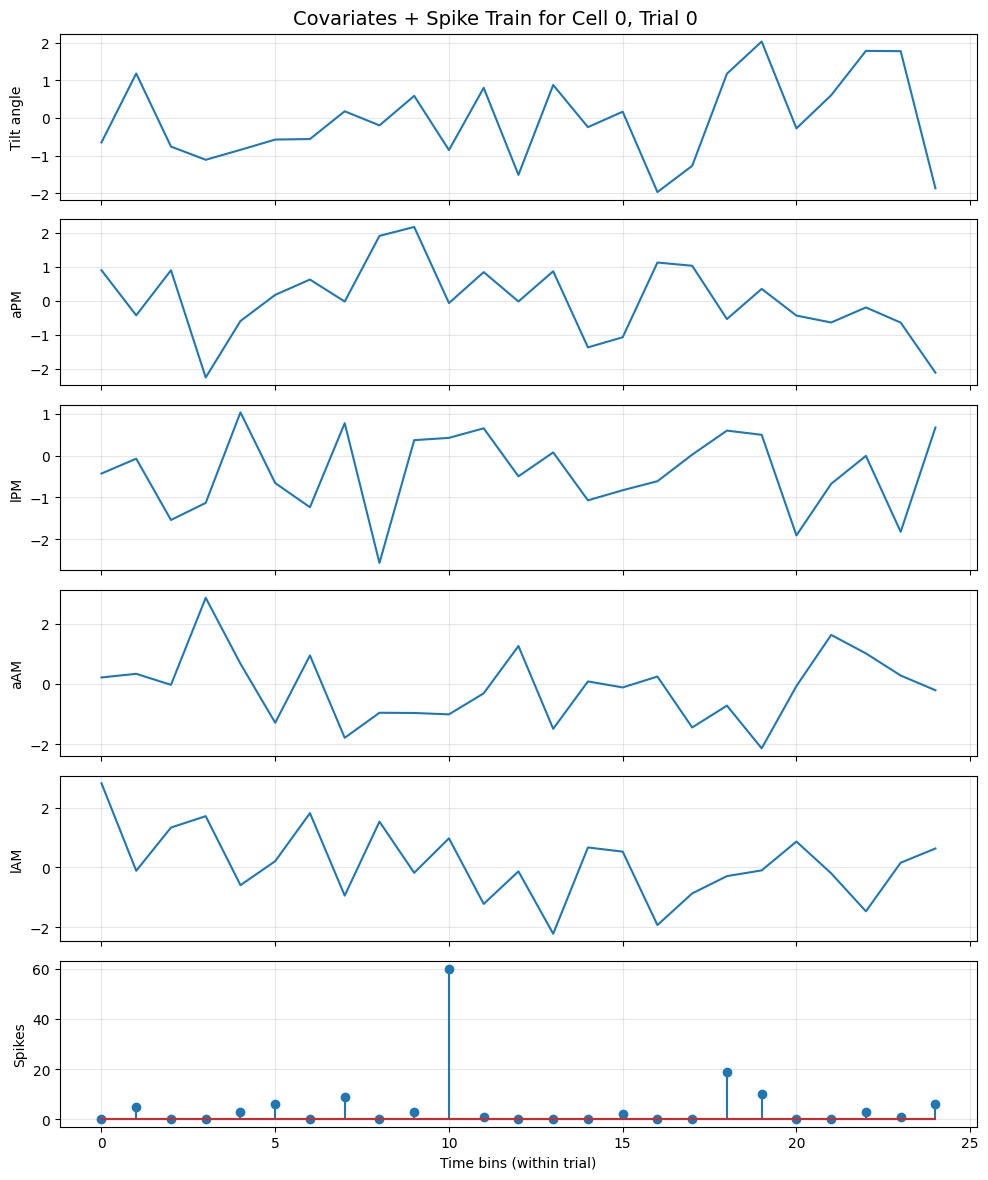

In [ ]:
# Plot covariates for a single cell and trial
# Covariate index	Meaning
# 0	Tilt angle
# 1	aPM (angular passive head speed)
# 2	lPM (linear passive head speed)
# 3	aAM (angular active head speed)
# 4	lAM (linear active head speed)

def get_cell_slice(cell_idx, bins_per_cell=3000):
    start = cell_idx * bins_per_cell
    end = (cell_idx + 1) * bins_per_cell
    return slice(start, end)

def get_trial_slice(cell_idx, trial_idx, bins_per_cell=3000, trials_per_cell=120):
    bins_per_trial = bins_per_cell // trials_per_cell
    cell_start = cell_idx * bins_per_cell
    trial_start = cell_start + trial_idx * bins_per_trial
    trial_end = trial_start + bins_per_trial
    return slice(trial_start, trial_end)

def plot_covariates_and_spikes(X, Y, cell_idx, trial_idx):

    # Your confirmed covariate order
    cov_names = [
        "Tilt angle",
        "aPM",
        "lPM",
        "aAM",
        "lAM"
    ]

    sl = get_trial_slice(cell_idx, trial_idx)
    X_trial = X[:, sl]
    Y_trial = Y[sl]

    n_cov = X_trial.shape[0]
    fig, axes = plt.subplots(n_cov + 1, 1, figsize=(10, 2*(n_cov+1)), sharex=True)

    for i in range(n_cov):
        axes[i].plot(X_trial[i])
        axes[i].set_ylabel(cov_names[i], fontsize=10)
        axes[i].grid(True, alpha=0.3)

    axes[-1].stem(Y_trial)
    axes[-1].set_ylabel("Spikes")
    axes[-1].set_xlabel("Time bins (within trial)")
    axes[-1].grid(True, alpha=0.3)

    plt.suptitle(f"Covariates + Spike Train for Cell {cell_idx}, Trial {trial_idx}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Example call
plot_covariates_and_spikes(X, Y, cell_idx=0, trial_idx=0)